# Actividad 1: EDA inicial del dataset REHAB

Este notebook realiza una exploracion inicial del subconjunto `Rehab_exercise` del reto. El enfoque sigue la guia de EDA compartida en clase, que organiza el analisis en tres bloques: **overview y estadistica descriptiva**, **evaluacion/visualizacion de variables** y **evaluacion de calidad de datos**.

Contexto del reto: REHAB es un dataset cinematico con sensores portatiles para investigacion en rehabilitacion posterior a accidente cerebrovascular. En este parcial nos enfocamos en los **16 movimientos de entrenamiento de rehabilitacion**.

Fuentes consultadas:

- Guia de EDA: [A Data Scientist's Essential Guide to Exploratory Data Analysis](https://towardsdatascience.com/a-data-scientists-essential-guide-to-exploratory-data-analysis-25637eee0cf6/) y su republicacion accesible en [KDnuggets](https://www.kdnuggets.com/2023/06/data-scientist-essential-guide-exploratory-data-analysis.html).
- Articulo del dataset: [Lv et al., Scientific Data, 2026](https://www.nature.com/articles/s41597-026-07802-2).


## 0. Objetivo y estructura

La meta de este EDA es entender que hay en los archivos, verificar dimensiones y consistencia entre sensores, identificar desbalance de clases, revisar distribuciones de canales y detectar problemas de calidad antes de construir modelos.

Estructura del notebook:

1. **Carga de datos y diccionario**: rutas, catalogo de movimientos y canales.
2. **Paso 1 - Overview y estadistica descriptiva**: inventario de archivos, dimensiones, conteos y resumen numerico.
3. **Paso 2 - Evaluacion y visualizacion de variables**: analisis univariado, multivariado, correlaciones e interaccion entre canales.
4. **Paso 3 - Calidad de datos**: archivos corruptos, valores faltantes, ceros, duplicados y recomendaciones.


## 1. Carga de librerias


In [1]:
from pathlib import Path
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 9

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 2. Diccionario de datos del reto

De acuerdo con el articulo de REHAB, los archivos del subconjunto de entrenamiento siguen el patron `<movementID>_<sensorID>.npy`:

- `movementID`: valores `000` a `015`, una clase por movimiento de entrenamiento.
- `sensorID = 1`: seis canales de angulos de dos sensores IMU. Para tren superior son `S1` y `S2`; para tren inferior son `S3` y `S4`.
- `sensorID = 2`: seis canales del guante/sensor `S5`, cinco flexiones de dedos y `pitch3`.
- Forma esperada de cada arreglo procesado: `(n_muestras, 880, 6)`.

El largo temporal `880` viene de la estandarizacion descrita por los autores; cada muestra contiene aproximadamente 8 a 10 ciclos de movimiento despues de truncamiento o padding.


In [2]:
def find_data_dir() -> Path:
    # Busca la carpeta de datos desde ubicaciones tipicas del notebook.
    candidates = [
        Path.cwd() / "Rehab_exercise" / "d02_processed_data",
        Path.cwd().parent / "Rehab_exercise" / "d02_processed_data",
        Path.cwd().parent.parent / "Rehab_exercise" / "d02_processed_data",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("No se encontro Rehab_exercise/d02_processed_data desde el directorio actual.")


DATA_DIR = find_data_dir()
PROJECT_ROOT = DATA_DIR.parents[1]
print(f"Carpeta de datos: {DATA_DIR}")

movement_catalog = pd.DataFrame([
    {"movement_id": "000", "movement_name": "bobath handshake", "movement_group": "Upper extremity combined training"},
    {"movement_id": "001", "movement_name": "bobath flexion/extension", "movement_group": "Upper extremity combined training"},
    {"movement_id": "002", "movement_name": "bobath forward flexion/extension", "movement_group": "Upper extremity combined training"},
    {"movement_id": "003", "movement_name": "bobath anterior/posterior rotation", "movement_group": "Upper extremity combined training"},
    {"movement_id": "004", "movement_name": "elbow flexion and wrist compression", "movement_group": "Upper extremity combined training"},
    {"movement_id": "005", "movement_name": "wrist flexion and extension", "movement_group": "Hands training"},
    {"movement_id": "006", "movement_name": "finger-to-finger training", "movement_group": "Hands training"},
    {"movement_id": "007", "movement_name": "ball gripping", "movement_group": "Hands training"},
    {"movement_id": "008", "movement_name": "shoulder joint internal and external", "movement_group": "Shoulder training"},
    {"movement_id": "009", "movement_name": "breast expansion", "movement_group": "Shoulder training"},
    {"movement_id": "010", "movement_name": "flexion-pressure rotation forward and backward", "movement_group": "Arm training"},
    {"movement_id": "011", "movement_name": "elbow joint flexion and touch", "movement_group": "Arm training"},
    {"movement_id": "012", "movement_name": "shoulder touch training", "movement_group": "Arm training"},
    {"movement_id": "013", "movement_name": "Ankle extension & Knee internal and external rotation", "movement_group": "Lower limbs training"},
    {"movement_id": "014", "movement_name": "knee flexion and extension", "movement_group": "Lower limbs training"},
    {"movement_id": "015", "movement_name": "Hip flexion and extension", "movement_group": "Lower limbs training"},
])

channel_names = {
    "1": ["pitch1", "yaw1", "roll1", "pitch2", "yaw2", "roll2"],
    "2": ["f1", "f2", "f3", "f4", "f5", "pitch3"],
}

sensor_descriptions = pd.DataFrame([
    {"sensor_id": "1", "represented_sensors": "S1/S2 en tren superior; S3/S4 en tren inferior", "channels": ", ".join(channel_names["1"])},
    {"sensor_id": "2", "represented_sensors": "S5: guante de rehabilitacion", "channels": ", ".join(channel_names["2"])},
])

display(movement_catalog)
display(sensor_descriptions)


Carpeta de datos: C:\Users\GetzemaniKinariRíosT\OneDrive - FANGIO COM\Desktop\Codex\Reto 1\Reto 1\Rehab_exercise\d02_processed_data


,movement_id,movement_name,movement_group
0,000,bobath handshake,Upper extremity combined training
1,001,bobath flexion/extension,Upper extremity combined training
2,002,bobath forward flexion/extension,Upper extremity combined training
3,003,bobath anterior/posterior rotation,Upper extremity combined training
4,004,elbow flexion and wrist compression,Upper extremity combined training
5,005,wrist flexion and extension,Hands training
6,006,finger-to-finger training,Hands training
7,007,ball gripping,Hands training
8,008,shoulder joint internal and external,Shoulder training
9,009,breast expansion,Shoulder training


,sensor_id,represented_sensors,channels
0,1,S1/S2 en tren superior; S3/S4 en tren inferior,"pitch1, yaw1, roll1, pitch2, yaw2, roll2"
1,2,S5: guante de rehabilitacion,"f1, f2, f3, f4, f5, pitch3"


## 3. Funciones auxiliares

Estas funciones cargan los arreglos `.npy`, generan el inventario de archivos y construyen features agregadas por muestra. Las features por muestra convierten cada senal 3D en una tabla 2D que podemos usar para histogramas, boxplots, correlaciones y PCA.


In [3]:
def parse_npy_name(path: Path) -> tuple[str, str]:
    movement_id, sensor_id = path.stem.split("_")
    return movement_id, sensor_id


def first_bytes_hex(path: Path, n: int = 12) -> str:
    with open(path, "rb") as fh:
        return fh.read(n).hex(" ")


def inspect_and_load_files(data_dir: Path):
    arrays = {}
    records = []
    for path in sorted(data_dir.glob("*.npy")):
        movement_id, sensor_id = parse_npy_name(path)
        record = {
            "file": path.name,
            "movement_id": movement_id,
            "sensor_id": sensor_id,
            "bytes": path.stat().st_size,
            "numpy_magic_ok": first_bytes_hex(path, 1) == "93",
            "status": "valid",
            "error": "",
        }
        try:
            arr = np.load(path)
            if arr.ndim != 3:
                raise ValueError(f"Se esperaban 3 dimensiones y llegaron {arr.ndim}.")
            record.update({
                "shape": arr.shape,
                "samples": arr.shape[0],
                "timesteps": arr.shape[1],
                "channels": arr.shape[2],
                "dtype": str(arr.dtype),
                "missing_values": int(np.isnan(arr).sum()),
                "infinite_values": int(np.isinf(arr).sum()),
                "zero_rate": float(np.mean(arr == 0)),
                "mean": float(np.mean(arr)),
                "median": float(np.median(arr)),
                "std": float(np.std(arr)),
                "min": float(np.min(arr)),
                "max": float(np.max(arr)),
            })
            arrays[(movement_id, sensor_id)] = arr
        except Exception as exc:
            record.update({
                "status": "error",
                "error": f"{type(exc).__name__}: {exc}",
                "shape": None,
                "samples": np.nan,
                "timesteps": np.nan,
                "channels": np.nan,
                "dtype": None,
                "missing_values": np.nan,
                "infinite_values": np.nan,
                "zero_rate": np.nan,
                "mean": np.nan,
                "median": np.nan,
                "std": np.nan,
                "min": np.nan,
                "max": np.nan,
            })
        records.append(record)

    inventory = pd.DataFrame(records).merge(movement_catalog, on="movement_id", how="left")
    inventory = inventory.sort_values(["movement_id", "sensor_id"]).reset_index(drop=True)
    return arrays, inventory


arrays, file_inventory = inspect_and_load_files(DATA_DIR)
valid_inventory = file_inventory[file_inventory["status"] == "valid"].copy()
load_errors = file_inventory[file_inventory["status"] != "valid"].copy()

print(f"Archivos encontrados: {len(file_inventory)}")
print(f"Archivos validos: {len(valid_inventory)}")
print(f"Archivos con error: {len(load_errors)}")


Archivos encontrados: 32
Archivos validos: 31
Archivos con error: 1


# Paso 1 - Overview y estadistica descriptiva

Este primer bloque responde la pregunta: **Con que datos estamos trabajando?** Aqui revisamos tamano, estructura, tipos, conteos por clase y estadisticas generales.


In [4]:
inventory_cols = [
    "file", "movement_id", "sensor_id", "movement_name", "movement_group", "status",
    "shape", "samples", "timesteps", "channels", "dtype", "bytes",
    "missing_values", "infinite_values", "zero_rate", "mean", "std", "min", "max", "error",
]
display(file_inventory[inventory_cols])


,file,movement_id,sensor_id,movement_name,movement_group,status,shape,samples,timesteps,channels,dtype,bytes,missing_values,infinite_values,zero_rate,mean,std,min,max,error
0,000_1.npy,000,1,bobath handshake,Upper extremity combined training,valid,"(232, 880, 6)",232.0000,880.0000,6.0000,float64,9799808,0.0000,0.0000,0.0000,-0.0000,31.9743,-320.8824,145.6909,
1,000_2.npy,000,2,bobath handshake,Upper extremity combined training,valid,"(232, 880, 6)",232.0000,880.0000,6.0000,float64,9799808,0.0000,0.0000,0.0000,0.0000,32.2961,-228.9120,164.7491,
2,001_1.npy,001,1,bobath flexion/extension,Upper extremity combined training,valid,"(212, 880, 6)",212.0000,880.0000,6.0000,float64,8955008,0.0000,0.0000,0.0330,-0.0000,22.8252,-136.0888,123.8025,
3,001_2.npy,001,2,bobath flexion/extension,Upper extremity combined training,valid,"(212, 880, 6)",212.0000,880.0000,6.0000,float64,8955008,0.0000,0.0000,0.0330,0.0000,30.2780,-209.1759,209.9552,
4,002_1.npy,002,1,bobath forward flexion/extension,Upper extremity combined training,valid,"(267, 880, 6)",267.0000,880.0000,6.0000,float64,11278208,0.0000,0.0000,0.0037,-0.0000,23.0549,-106.8444,137.8554,
5,002_2.npy,002,2,bobath forward flexion/extension,Upper extremity combined training,valid,"(267, 880, 6)",267.0000,880.0000,6.0000,float64,11278208,0.0000,0.0000,0.0037,0.0000,30.9736,-168.8155,209.9776,
6,003_1.npy,003,1,bobath anterior/posterior rotation,Upper extremity combined training,valid,"(250, 880, 6)",250.0000,880.0000,6.0000,float64,10560128,0.0000,0.0000,0.0000,0.0000,23.4127,-148.1304,143.3635,
7,003_2.npy,003,2,bobath anterior/posterior rotation,Upper extremity combined training,valid,"(250, 880, 6)",250.0000,880.0000,6.0000,float64,10560128,0.0000,0.0000,0.0000,0.0000,39.2568,-254.3601,223.9142,
8,004_1.npy,004,1,elbow flexion and wrist compression,Upper extremity combined training,valid,"(287, 880, 6)",287.0000,880.0000,6.0000,float64,12123008,0.0000,0.0000,0.0401,-0.0000,19.4769,-606.1859,870.0059,
9,004_2.npy,004,2,elbow flexion and wrist compression,Upper extremity combined training,valid,"(287, 880, 6)",287.0000,880.0000,6.0000,float64,12123008,0.0000,0.0000,0.0383,0.0000,38.4179,-338.9933,348.4852,


In [5]:
# Para contar clases usamos sensor_id = 2 porque esta disponible para los 16 movimientos.
activity_counts = (
    valid_inventory[valid_inventory["sensor_id"] == "2"]
    [["movement_id", "movement_name", "movement_group", "samples"]]
    .sort_values("movement_id")
    .reset_index(drop=True)
)

overview = pd.DataFrame([
    {"metric": "movimientos de entrenamiento", "value": activity_counts["movement_id"].nunique()},
    {"metric": "muestras totales con sensor_id=2", "value": int(activity_counts["samples"].sum())},
    {"metric": "longitud temporal estandarizada", "value": int(valid_inventory["timesteps"].dropna().mode().iloc[0])},
    {"metric": "canales por archivo", "value": int(valid_inventory["channels"].dropna().mode().iloc[0])},
    {"metric": "archivos esperados", "value": 32},
    {"metric": "archivos validos", "value": int((file_inventory["status"] == "valid").sum())},
    {"metric": "archivos con error", "value": int((file_inventory["status"] != "valid").sum())},
    {"metric": "minimo de muestras por movimiento", "value": int(activity_counts["samples"].min())},
    {"metric": "maximo de muestras por movimiento", "value": int(activity_counts["samples"].max())},
    {"metric": "ratio max/min de muestras", "value": round(float(activity_counts["samples"].max() / activity_counts["samples"].min()), 3)},
])

display(overview)
display(activity_counts)


,metric,value
0,movimientos de entrenamiento,16.0000
1,muestras totales con sensor_id=2,"4,616.0000"
2,longitud temporal estandarizada,880.0000
3,canales por archivo,6.0000
4,archivos esperados,32.0000
5,archivos validos,31.0000
6,archivos con error,1.0000
7,minimo de muestras por movimiento,212.0000
8,maximo de muestras por movimiento,385.0000
9,ratio max/min de muestras,1.8160


,movement_id,movement_name,movement_group,samples
0,000,bobath handshake,Upper extremity combined training,232.0000
1,001,bobath flexion/extension,Upper extremity combined training,212.0000
2,002,bobath forward flexion/extension,Upper extremity combined training,267.0000
3,003,bobath anterior/posterior rotation,Upper extremity combined training,250.0000
4,004,elbow flexion and wrist compression,Upper extremity combined training,287.0000
5,005,wrist flexion and extension,Hands training,293.0000
6,006,finger-to-finger training,Hands training,260.0000
7,007,ball gripping,Hands training,385.0000
8,008,shoulder joint internal and external,Shoulder training,299.0000
9,009,breast expansion,Shoulder training,307.0000


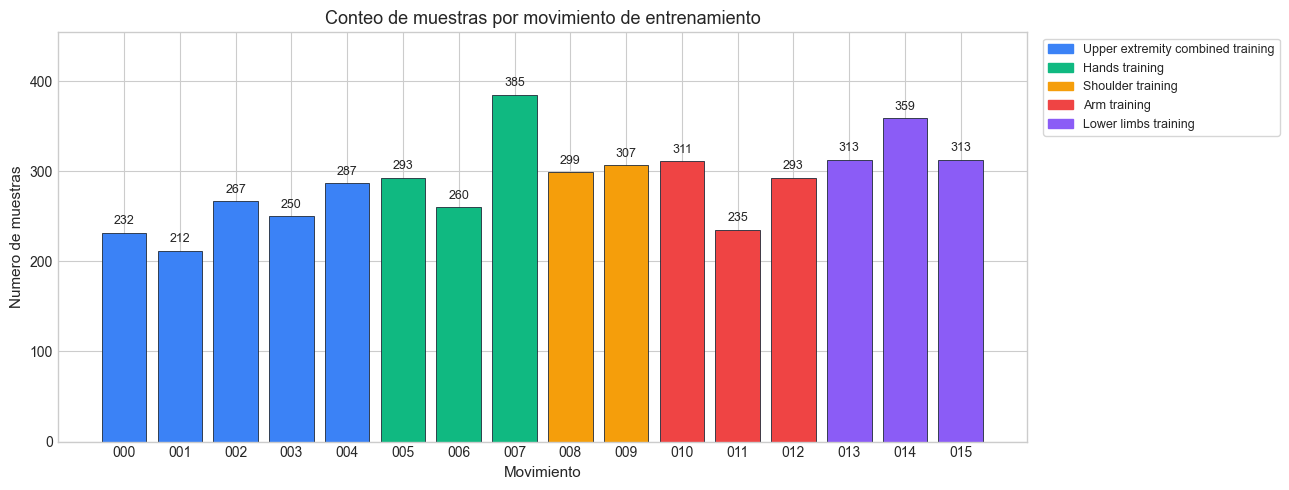

In [6]:
group_colors = {
    "Upper extremity combined training": "#3b82f6",
    "Hands training": "#10b981",
    "Shoulder training": "#f59e0b",
    "Arm training": "#ef4444",
    "Lower limbs training": "#8b5cf6",
}

fig, ax = plt.subplots(figsize=(13, 5))
colors = activity_counts["movement_group"].map(group_colors)
bars = ax.bar(activity_counts["movement_id"], activity_counts["samples"], color=colors, edgecolor="#1f2937", linewidth=0.6)
ax.set_title("Conteo de muestras por movimiento de entrenamiento")
ax.set_xlabel("Movimiento")
ax.set_ylabel("Numero de muestras")
ax.set_ylim(0, activity_counts["samples"].max() * 1.18)
for bar, value in zip(bars, activity_counts["samples"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 6, str(int(value)), ha="center", va="bottom", fontsize=9)
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in group_colors.values()]
ax.legend(handles, list(group_colors.keys()), loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True)
plt.tight_layout()
plt.show()


### Hallazgos del overview

- La estructura esperada es consistente con el articulo: cada muestra procesada tiene `880` puntos temporales y `6` canales por configuracion de sensor.
- Usando `sensor_id=2`, hay **4,616 muestras** repartidas en los 16 movimientos de entrenamiento. Este total coincide con el numero de muestras procesadas reportado por los autores despues de remover errores.
- Los conteos no estan perfectamente balanceados: el movimiento `001` tiene 212 muestras y el movimiento `007` tiene 385. El ratio maximo/minimo es aproximadamente 1.82.
- Se detecta un archivo problematico: `014_1.npy`. El archivo `014_2.npy` si carga correctamente, por eso el movimiento 014 puede analizarse con el sensor S5, pero no con la configuracion `sensor_id=1`.


## 4. Consistencia entre configuraciones de sensor

Antes de visualizar canales, verificamos si los archivos `_1` y `_2` de cada movimiento tienen el mismo numero de muestras. Esto no significa que tengan las mismas lecturas: representan sensores/canales diferentes. Si nos sirve para confirmar que ambas configuraciones se alinean por movimiento.


In [7]:
pair_rows = []
for movement_id in movement_catalog["movement_id"]:
    row_1 = valid_inventory[(valid_inventory["movement_id"] == movement_id) & (valid_inventory["sensor_id"] == "1")]
    row_2 = valid_inventory[(valid_inventory["movement_id"] == movement_id) & (valid_inventory["sensor_id"] == "2")]
    samples_1 = None if row_1.empty else int(row_1.iloc[0]["samples"])
    samples_2 = None if row_2.empty else int(row_2.iloc[0]["samples"])
    pair_rows.append({
        "movement_id": movement_id,
        "movement_name": movement_catalog.loc[movement_catalog["movement_id"] == movement_id, "movement_name"].iloc[0],
        "sensor_1_valid": not row_1.empty,
        "sensor_2_valid": not row_2.empty,
        "samples_sensor_1": samples_1,
        "samples_sensor_2": samples_2,
        "same_sample_count": (samples_1 == samples_2) if samples_1 is not None and samples_2 is not None else False,
    })

sensor_pair_check = pd.DataFrame(pair_rows)
display(sensor_pair_check)


,movement_id,movement_name,sensor_1_valid,sensor_2_valid,samples_sensor_1,samples_sensor_2,same_sample_count
0,000,bobath handshake,True,True,232.0000,232,True
1,001,bobath flexion/extension,True,True,212.0000,212,True
2,002,bobath forward flexion/extension,True,True,267.0000,267,True
3,003,bobath anterior/posterior rotation,True,True,250.0000,250,True
4,004,elbow flexion and wrist compression,True,True,287.0000,287,True
5,005,wrist flexion and extension,True,True,293.0000,293,True
6,006,finger-to-finger training,True,True,260.0000,260,True
7,007,ball gripping,True,True,385.0000,385,True
8,008,shoulder joint internal and external,True,True,299.0000,299,True
9,009,breast expansion,True,True,307.0000,307,True


# Paso 2 - Evaluacion y visualizacion de variables

En este bloque pasamos del inventario a las variables. Para datos de sensores, una variable no es una columna tabular original, sino un canal medido a traves del tiempo. Por eso revisamos:

- Senales temporales de una repeticion.
- Distribuciones de valores por canal.
- Features agregadas por muestra: media, desviacion estandar, minimo, maximo, rango y RMS.
- Relaciones entre canales mediante correlaciones, scatterplots y PCA.


In [8]:
def build_sample_features(arrays: dict, sensor_id: str) -> pd.DataFrame:
    rows = []
    channels = channel_names[sensor_id]
    for (movement_id, sid), arr in arrays.items():
        if sid != sensor_id:
            continue
        means = arr.mean(axis=1)
        stds = arr.std(axis=1)
        mins = arr.min(axis=1)
        maxs = arr.max(axis=1)
        ranges = maxs - mins
        rms = np.sqrt(np.mean(np.square(arr), axis=1))
        zero_fraction = np.mean(arr == 0, axis=(1, 2))
        all_zero = np.all(arr == 0, axis=(1, 2))

        for sample_idx in range(arr.shape[0]):
            record = {
                "movement_id": movement_id,
                "sensor_id": sid,
                "sample_idx": sample_idx,
                "zero_fraction": float(zero_fraction[sample_idx]),
                "all_zero_sample": bool(all_zero[sample_idx]),
            }
            for channel_idx, channel in enumerate(channels):
                record[f"{channel}_mean"] = float(means[sample_idx, channel_idx])
                record[f"{channel}_std"] = float(stds[sample_idx, channel_idx])
                record[f"{channel}_min"] = float(mins[sample_idx, channel_idx])
                record[f"{channel}_max"] = float(maxs[sample_idx, channel_idx])
                record[f"{channel}_range"] = float(ranges[sample_idx, channel_idx])
                record[f"{channel}_rms"] = float(rms[sample_idx, channel_idx])
            rows.append(record)

    features = pd.DataFrame(rows).merge(movement_catalog, on="movement_id", how="left")
    return features.sort_values(["movement_id", "sample_idx"]).reset_index(drop=True)


features_s1 = build_sample_features(arrays, "1")
features_s2 = build_sample_features(arrays, "2")

print(f"Features sensor_id=1: {features_s1.shape}")
print(f"Features sensor_id=2: {features_s2.shape}")
display(features_s2.head())


Features sensor_id=1: (4257, 43)
Features sensor_id=2: (4616, 43)


,movement_id,sensor_id,sample_idx,zero_fraction,all_zero_sample,f1_mean,f1_std,f1_min,f1_max,f1_range,f1_rms,f2_mean,f2_std,f2_min,f2_max,f2_range,f2_rms,f3_mean,f3_std,f3_min,f3_max,f3_range,f3_rms,f4_mean,f4_std,f4_min,f4_max,f4_range,f4_rms,f5_mean,f5_std,f5_min,f5_max,f5_range,f5_rms,pitch3_mean,pitch3_std,pitch3_min,pitch3_max,pitch3_range,pitch3_rms,movement_name,movement_group
0,000,2,0,0.0000,False,-0.0000,29.2584,-30.8383,59.3617,90.2000,29.2584,-0.0000,8.3260,-15.6639,8.4361,24.1000,8.3260,-0.0000,6.9296,-14.4574,6.8426,21.3000,6.9296,0.0000,5.0090,-11.7495,8.7505,20.5000,5.0090,-0.0000,3.4283,-9.2456,6.3544,15.6000,3.4283,0.0000,77.2339,-95.2839,117.6909,212.9747,77.2339,bobath handshake,Upper extremity combined training
1,000,2,1,0.0000,False,0.0000,29.8203,-31.6909,57.4091,89.1000,29.8203,0.0000,8.0661,-15.2727,8.7273,24.0000,8.0661,0.0000,6.7322,-14.3307,6.5693,20.9000,6.7322,-0.0000,4.7513,-12.2498,8.5502,20.8000,4.7513,-0.0000,2.9188,-10.1380,5.5620,15.7000,2.9188,-0.0000,78.2821,-93.9399,115.2470,209.1869,78.2821,bobath handshake,Upper extremity combined training
2,000,2,2,0.0000,False,0.0000,26.3645,-30.2140,60.7860,91.0000,26.3645,0.0000,7.6373,-14.1460,8.2540,22.4000,7.6373,-0.0000,6.4576,-14.8261,6.5739,21.4000,6.4576,0.0000,4.4431,-12.4994,9.0006,21.5000,4.4431,0.0000,2.4765,-10.5625,5.8375,16.4000,2.4765,0.0000,76.9470,-84.6228,116.4115,201.0343,76.9470,bobath handshake,Upper extremity combined training
3,000,2,3,0.0000,False,-0.0000,1.7398,-11.6249,5.9751,17.6000,1.7398,0.0000,10.3711,-17.7360,14.6640,32.4000,10.3711,-0.0000,8.2104,-14.0275,11.2725,25.3000,8.2104,0.0000,9.3549,-20.4328,22.0672,42.5000,9.3549,-0.0000,4.2415,-12.2188,15.1813,27.4000,4.2415,0.0000,87.5272,-144.6762,128.9953,273.6716,87.5272,bobath handshake,Upper extremity combined training
4,000,2,4,0.0000,False,0.0000,1.6468,-12.3807,6.1193,18.5000,1.6468,-0.0000,9.9813,-17.2549,15.1451,32.4000,9.9813,0.0000,8.0223,-13.4132,11.3868,24.8000,8.0223,-0.0000,9.1284,-18.6666,22.3334,41.0000,9.1284,0.0000,4.1740,-10.2295,15.5705,25.8000,4.1740,-0.0000,87.1417,-147.6315,126.0401,273.6716,87.1417,bobath handshake,Upper extremity combined training


## 5. Analisis univariado: senales y distribuciones

Primero observamos una repeticion individual. Esto permite revisar si los canales tienen forma temporal razonable y si hay cambios de escala entre sensores.


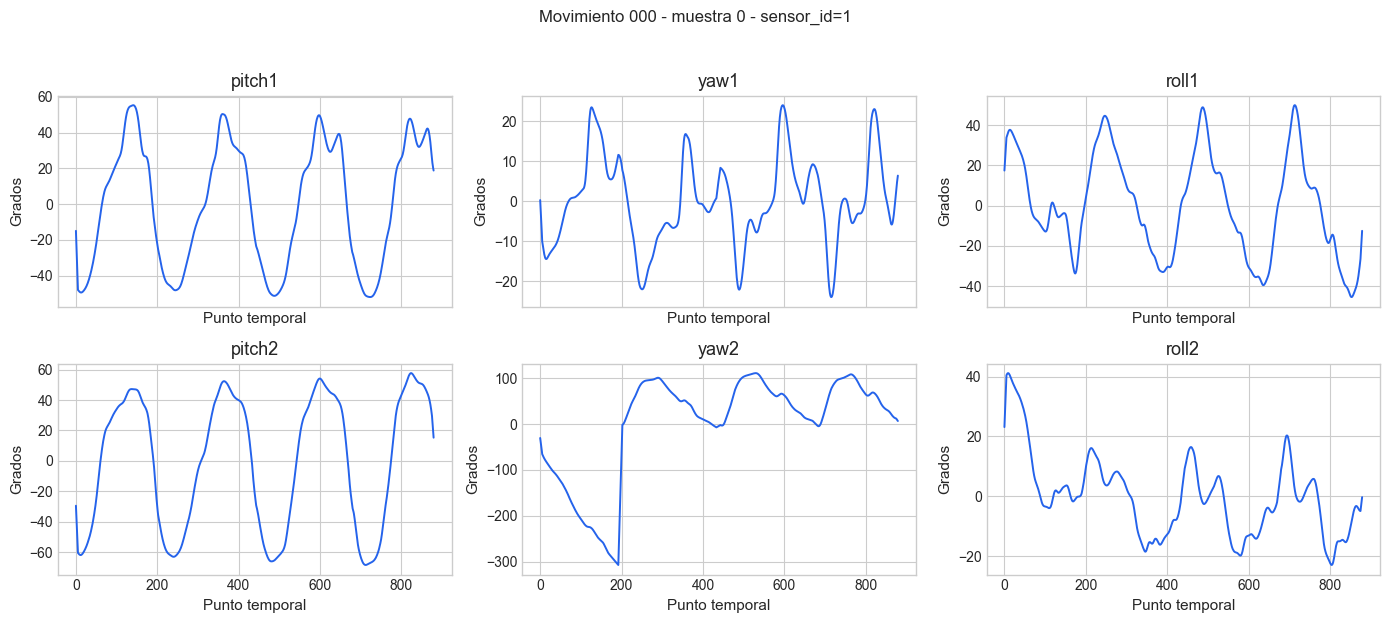

In [9]:
selected_movement = "000"
selected_sensor = "1"
selected_sample = 0
arr = arrays[(selected_movement, selected_sensor)]
channels = channel_names[selected_sensor]

time = np.arange(arr.shape[1])
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for channel_idx, ax in enumerate(axes.ravel()):
    ax.plot(time, arr[selected_sample, :, channel_idx], linewidth=1.4, color="#2563eb")
    ax.set_title(channels[channel_idx])
    ax.set_xlabel("Punto temporal")
    ax.set_ylabel("Grados")
fig.suptitle(f"Movimiento {selected_movement} - muestra {selected_sample} - sensor_id={selected_sensor}", y=1.03)
plt.tight_layout()
plt.show()


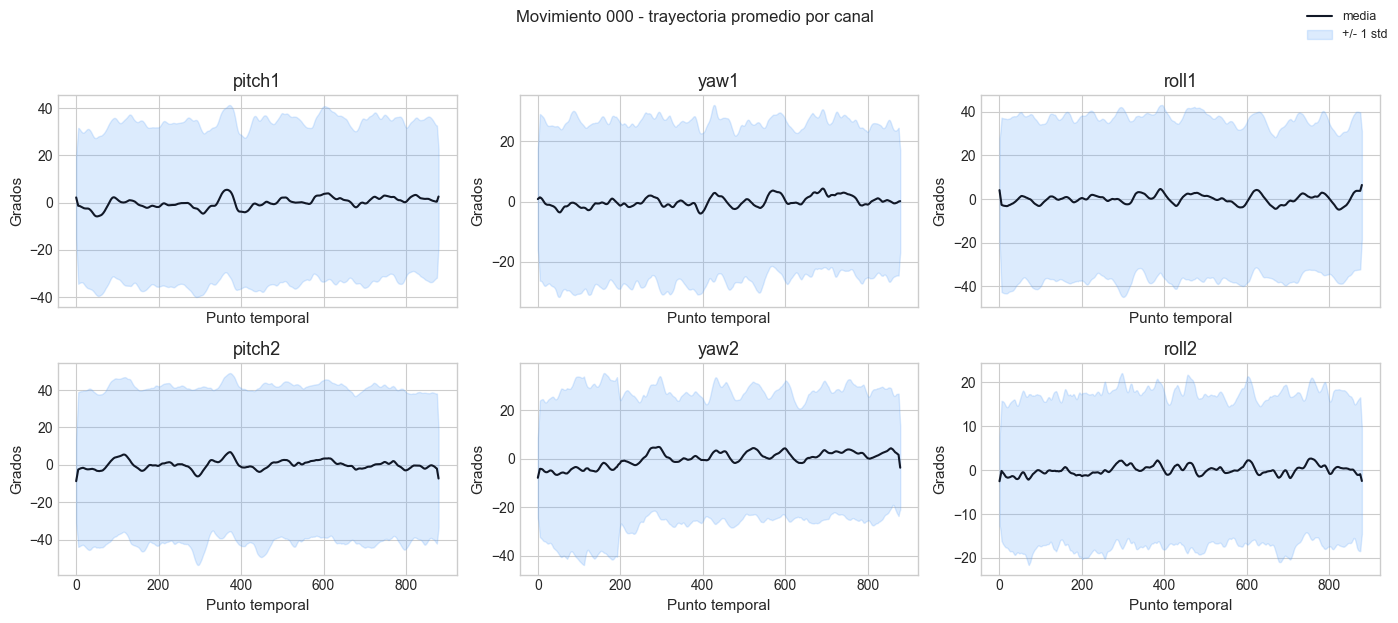

In [10]:
selected_movement = "000"
selected_sensor = "1"
arr = arrays[(selected_movement, selected_sensor)]
channels = channel_names[selected_sensor]

time = np.arange(arr.shape[1])
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for channel_idx, ax in enumerate(axes.ravel()):
    mean_signal = arr[:, :, channel_idx].mean(axis=0)
    std_signal = arr[:, :, channel_idx].std(axis=0)
    ax.plot(time, mean_signal, linewidth=1.5, color="#111827", label="media")
    ax.fill_between(time, mean_signal - std_signal, mean_signal + std_signal, alpha=0.22, color="#60a5fa", label="+/- 1 std")
    ax.set_title(channels[channel_idx])
    ax.set_xlabel("Punto temporal")
    ax.set_ylabel("Grados")
handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle(f"Movimiento {selected_movement} - trayectoria promedio por canal", y=1.03)
plt.tight_layout()
plt.show()


In [11]:
def channel_summary_table(arrays: dict) -> pd.DataFrame:
    rows = []
    for (movement_id, sensor_id), arr in arrays.items():
        for channel_idx, channel in enumerate(channel_names[sensor_id]):
            values = arr[:, :, channel_idx].ravel()
            q1, q3 = np.percentile(values, [25, 75])
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            rows.append({
                "movement_id": movement_id,
                "sensor_id": sensor_id,
                "channel": channel,
                "count": values.size,
                "mean": np.mean(values),
                "median": np.median(values),
                "std": np.std(values),
                "min": np.min(values),
                "q1": q1,
                "q3": q3,
                "max": np.max(values),
                "zero_rate": np.mean(values == 0),
                "iqr_outlier_rate": np.mean((values < lower) | (values > upper)) if iqr > 0 else 0,
            })
    summary = pd.DataFrame(rows).merge(movement_catalog, on="movement_id", how="left")
    return summary.sort_values(["sensor_id", "movement_id", "channel"]).reset_index(drop=True)


channel_summary = channel_summary_table(arrays)
display(channel_summary.head(20))


,movement_id,sensor_id,channel,count,mean,median,std,min,q1,q3,max,zero_rate,iqr_outlier_rate,movement_name,movement_group
0,000,1,pitch1,204160,-0.0000,1.5873,34.3514,-74.6715,-31.3321,26.0555,92.5951,0.0000,0.0000,bobath handshake,Upper extremity combined training
1,000,1,pitch2,204160,-0.0000,9.4658,41.7491,-101.0779,-39.4908,36.4026,84.5709,0.0000,0.0000,bobath handshake,Upper extremity combined training
2,000,1,roll1,204160,0.0000,-4.4605,37.0903,-155.1369,-28.1594,27.4650,145.6909,0.0000,0.0053,bobath handshake,Upper extremity combined training
3,000,1,roll2,204160,-0.0000,-1.0857,17.5517,-92.9120,-10.7691,8.4448,124.0835,0.0000,0.0428,bobath handshake,Upper extremity combined training
4,000,1,yaw1,204160,-0.0000,-1.2825,26.5654,-200.0003,-16.5978,17.5341,115.9344,0.0000,0.0199,bobath handshake,Upper extremity combined training
5,000,1,yaw2,204160,-0.0000,-2.3018,28.6642,-320.8824,-15.5706,13.2788,110.8370,0.0000,0.0480,bobath handshake,Upper extremity combined training
6,001,1,pitch1,186560,0.0000,0.0000,28.4697,-55.7143,-25.6057,21.7944,94.8917,0.0330,0.0000,bobath flexion/extension,Upper extremity combined training
7,001,1,pitch2,186560,-0.0000,0.0227,15.1680,-56.7660,-6.8060,9.3550,38.8158,0.0330,0.0452,bobath flexion/extension,Upper extremity combined training
8,001,1,roll1,186560,-0.0000,0.9277,32.7771,-108.2077,-22.8495,18.9109,123.8025,0.0330,0.0128,bobath flexion/extension,Upper extremity combined training
9,001,1,roll2,186560,0.0000,0.0128,8.5861,-69.1766,-3.4029,3.7528,75.4185,0.0330,0.0801,bobath flexion/extension,Upper extremity combined training


In [12]:
# Tabla solicitada: media y mediana de un canal elegido por actividad.
# Usamos pitch1 de sensor_id=1. El movimiento 014 no aparece porque 014_1.npy esta corrupto.
selected_channel = "pitch1"
selected_sensor = "1"
selected_channel_idx = channel_names[selected_sensor].index(selected_channel)

rows = []
for movement_id in movement_catalog["movement_id"]:
    arr = arrays.get((movement_id, selected_sensor))
    if arr is None:
        rows.append({"movement_id": movement_id, "movement_name": movement_catalog.loc[movement_catalog["movement_id"] == movement_id, "movement_name"].iloc[0], "mean": np.nan, "median": np.nan, "note": "sin archivo valido"})
        continue
    values = arr[:, :, selected_channel_idx].ravel()
    rows.append({
        "movement_id": movement_id,
        "movement_name": movement_catalog.loc[movement_catalog["movement_id"] == movement_id, "movement_name"].iloc[0],
        "mean": np.mean(values),
        "median": np.median(values),
        "note": "ok",
    })

pitch1_activity_summary = pd.DataFrame(rows)
display(pitch1_activity_summary)


,movement_id,movement_name,mean,median,note
0,000,bobath handshake,-0.0000,1.5873,ok
1,001,bobath flexion/extension,0.0000,0.0000,ok
2,002,bobath forward flexion/extension,-0.0000,1.0925,ok
3,003,bobath anterior/posterior rotation,-0.0000,-3.5531,ok
4,004,elbow flexion and wrist compression,0.0000,0.0000,ok
5,005,wrist flexion and extension,-0.0000,0.0000,ok
6,006,finger-to-finger training,0.0000,0.0000,ok
7,007,ball gripping,0.0000,-0.0505,ok
8,008,shoulder joint internal and external,-0.0000,-3.1788,ok
9,009,breast expansion,0.0000,-1.9694,ok


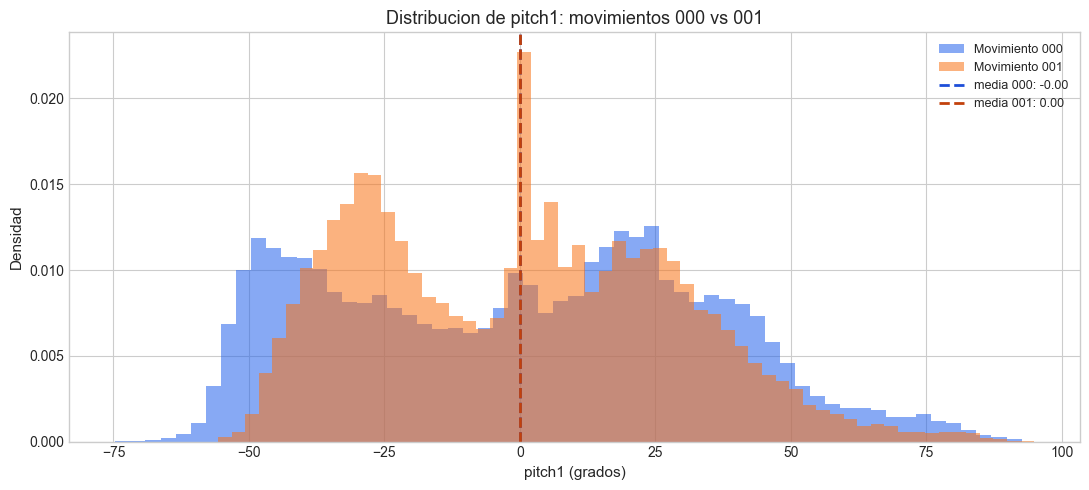

In [13]:
# Histograma solicitado: dos actividades en el mismo canal.
activity_a = "000"
activity_b = "001"
selected_channel = "pitch1"
selected_sensor = "1"
channel_idx = channel_names[selected_sensor].index(selected_channel)

values_a = arrays[(activity_a, selected_sensor)][:, :, channel_idx].ravel()
values_b = arrays[(activity_b, selected_sensor)][:, :, channel_idx].ravel()

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(values_a, bins=60, alpha=0.55, density=True, label=f"Movimiento {activity_a}", color="#2563eb")
ax.hist(values_b, bins=60, alpha=0.55, density=True, label=f"Movimiento {activity_b}", color="#f97316")
ax.axvline(np.mean(values_a), color="#1d4ed8", linestyle="--", linewidth=2, label=f"media {activity_a}: {np.mean(values_a):.2f}")
ax.axvline(np.mean(values_b), color="#c2410c", linestyle="--", linewidth=2, label=f"media {activity_b}: {np.mean(values_b):.2f}")
ax.set_title(f"Distribucion de {selected_channel}: movimientos {activity_a} vs {activity_b}")
ax.set_xlabel(f"{selected_channel} (grados)")
ax.set_ylabel("Densidad")
ax.legend()
plt.tight_layout()
plt.show()


C:\Users\GetzemaniKinariRíosT\AppData\Local\Temp\ipykernel_20296\2597325401.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


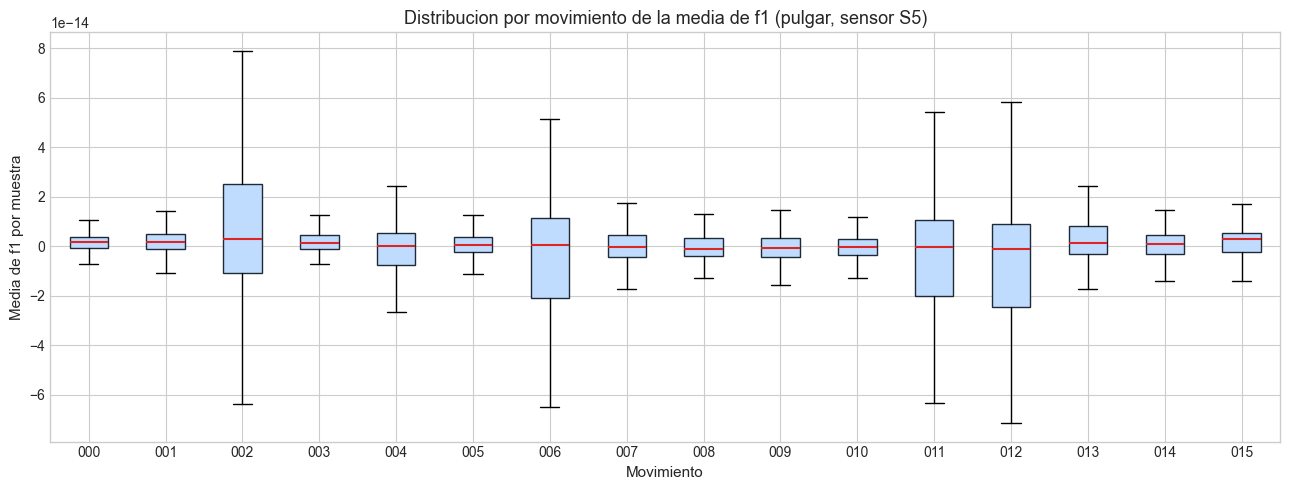

In [14]:
# Boxplot de una feature agregada por muestra.
box_feature = "f1_mean"
plot_data = [
    features_s2.loc[features_s2["movement_id"] == movement_id, box_feature].dropna().values
    for movement_id in activity_counts["movement_id"]
]

fig, ax = plt.subplots(figsize=(13, 5))
ax.boxplot(
    plot_data,
    labels=activity_counts["movement_id"],
    showfliers=False,
    patch_artist=True,
    boxprops={"facecolor": "#bfdbfe", "edgecolor": "#1f2937"},
    medianprops={"color": "#dc2626", "linewidth": 1.5},
)
ax.set_title("Distribucion por movimiento de la media de f1 (pulgar, sensor S5)")
ax.set_xlabel("Movimiento")
ax.set_ylabel("Media de f1 por muestra")
plt.tight_layout()
plt.show()


### Lectura del analisis univariado

- Las senales ya estan centradas cerca de cero, consistente con la normalizacion de media cero mencionada en el articulo.
- Los histogramas de `pitch1` para los movimientos `000` y `001` se traslapan bastante; un solo canal crudo no separa claramente las clases.
- Las features agregadas por muestra, como medias, rangos, desviaciones estandar y RMS, resumen la dinamica temporal y facilitan revisar separabilidad entre movimientos.


## 6. Analisis multivariado: interacciones y correlaciones

La guia de EDA recomienda analizar interacciones y correlaciones. Aqui usamos las features agregadas del sensor `S5` (`sensor_id=2`) porque este sensor esta disponible para los 16 movimientos.


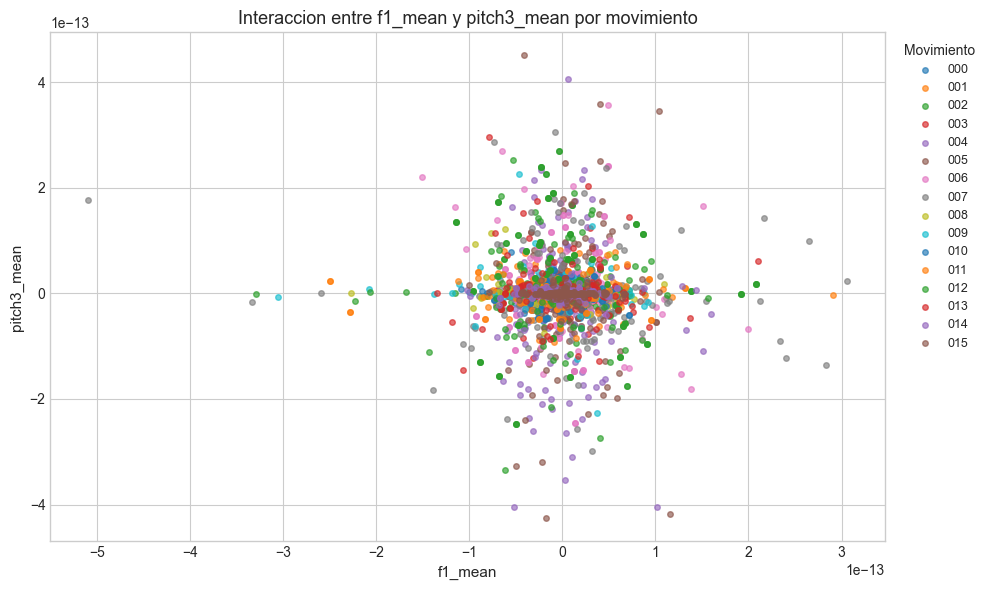

In [15]:
scatter_x = "f1_mean"
scatter_y = "pitch3_mean"
fig, ax = plt.subplots(figsize=(10, 6))

for movement_id, group_df in features_s2.groupby("movement_id"):
    ax.scatter(group_df[scatter_x], group_df[scatter_y], s=16, alpha=0.65, label=movement_id)

ax.set_title("Interaccion entre f1_mean y pitch3_mean por movimiento")
ax.set_xlabel(scatter_x)
ax.set_ylabel(scatter_y)
ax.legend(title="Movimiento", bbox_to_anchor=(1.01, 1), loc="upper left", ncols=1)
plt.tight_layout()
plt.show()


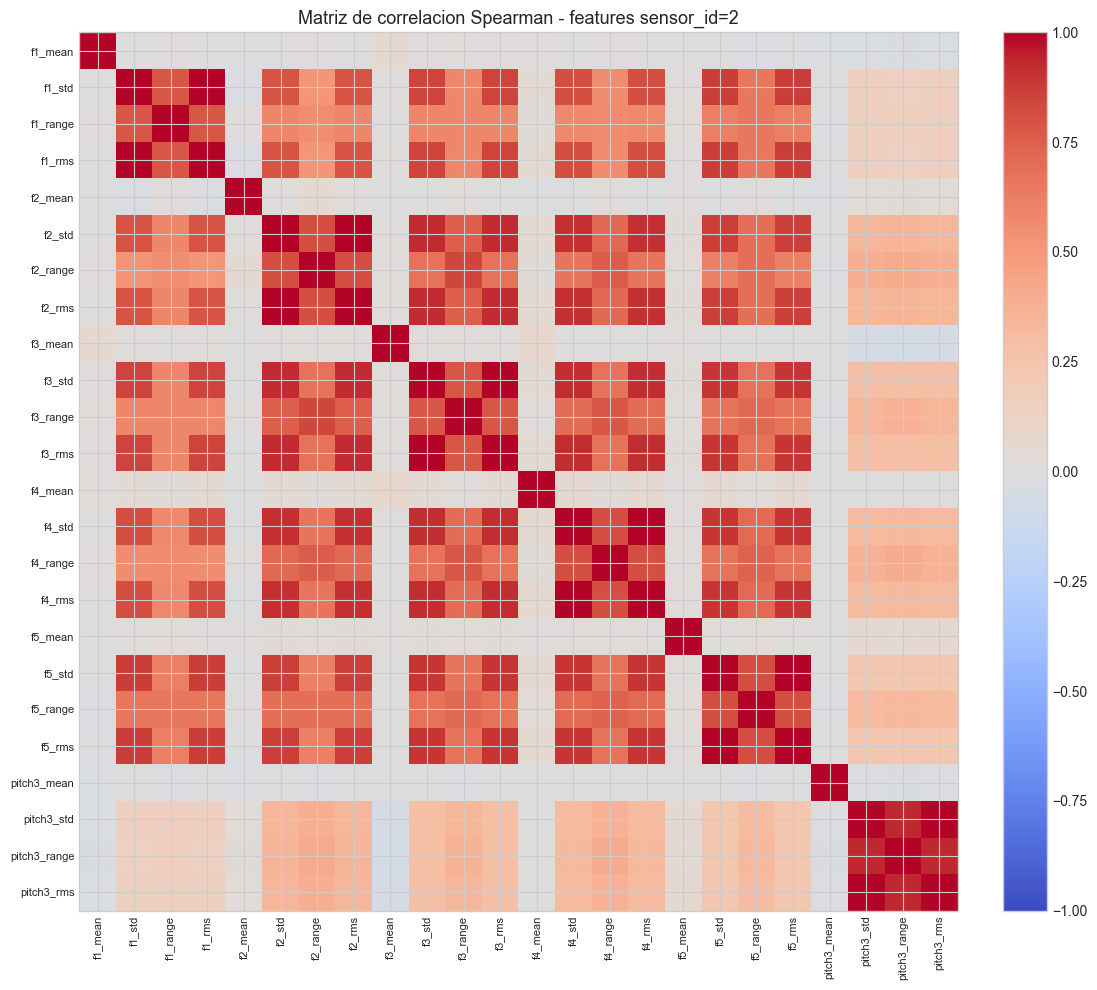

In [16]:
# Correlacion entre features numericas del sensor S5.
feature_cols_s2 = [
    col for col in features_s2.columns
    if col.endswith(("_mean", "_std", "_range", "_rms"))
]

corr = features_s2[feature_cols_s2].corr(method="spearman")

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr.index, fontsize=8)
ax.set_title("Matriz de correlacion Spearman - features sensor_id=2")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


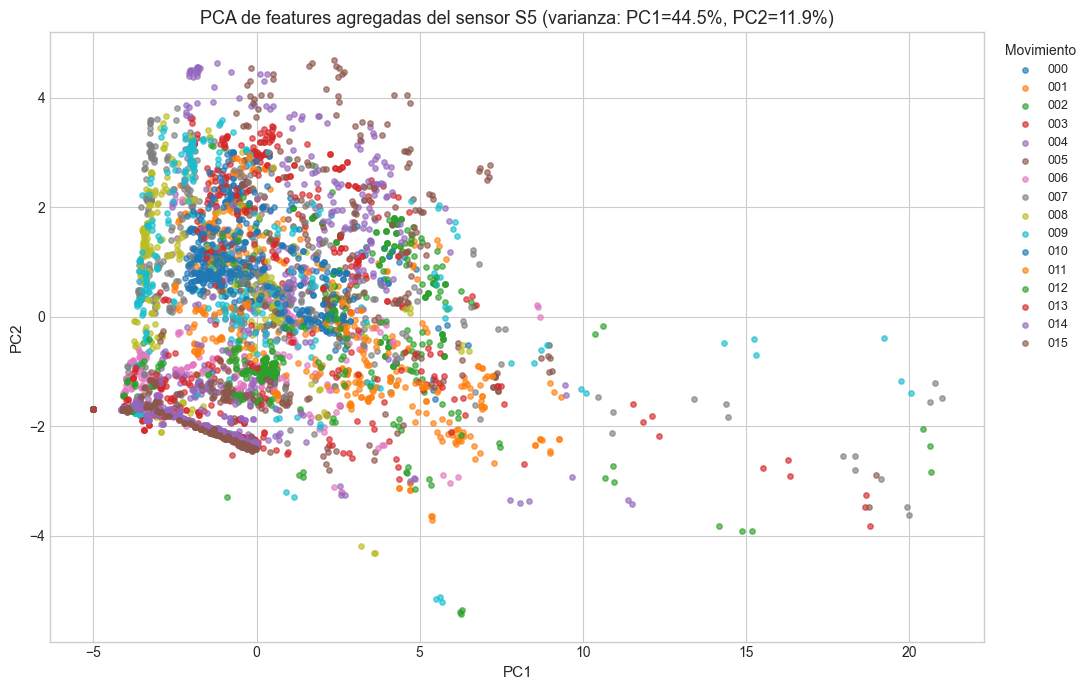

In [17]:
# PCA para visualizar separacion global con features del sensor S5.
try:
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA

    pca_features = features_s2[feature_cols_s2].fillna(0)
    X_scaled = StandardScaler().fit_transform(pca_features)
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_scaled)
    pca_df = features_s2[["movement_id", "movement_name", "movement_group"]].copy()
    pca_df["PC1"] = coords[:, 0]
    pca_df["PC2"] = coords[:, 1]

    fig, ax = plt.subplots(figsize=(11, 7))
    for movement_id, group_df in pca_df.groupby("movement_id"):
        ax.scatter(group_df["PC1"], group_df["PC2"], s=15, alpha=0.65, label=movement_id)
    ax.set_title(
        "PCA de features agregadas del sensor S5 "
        f"(varianza: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%})"
    )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(title="Movimiento", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"No se pudo ejecutar PCA con scikit-learn: {exc}")


## 7. Comparacion entre sensores dentro de `sensor_id=1`

En los archivos `_1`, los primeros tres canales corresponden a un sensor y los ultimos tres a otro sensor: `pitch1/yaw1/roll1` frente a `pitch2/yaw2/roll2`. Para verificar si las lecturas corresponden entre si, calculamos correlaciones por movimiento y por eje.

Interpretacion esperada: no deben ser identicas, porque provienen de sensores colocados en segmentos corporales diferentes. Una correlacion alta indica que ambos segmentos se movieron de manera coordinada en ese eje; una correlacion baja o negativa indica movimientos distintos o compensaciones.


angle,pitch,roll,yaw
movement_id,,,
000,0.8310,0.0800,0.1860
001,0.3200,0.0410,0.2220
002,0.1920,-0.3220,0.3110
003,0.5510,0.4560,0.1790
004,-0.0990,0.0730,-0.0610
005,-0.3050,0.0580,-0.1210
006,0.7460,-0.0580,0.5050
007,-0.1520,0.6090,0.0190
008,0.6010,-0.2820,0.0980


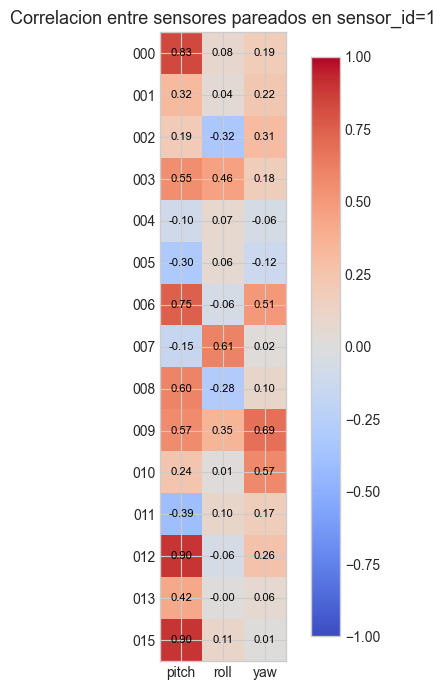

In [18]:
pair_corr_rows = []
angle_pairs = [("pitch", 0, 3), ("yaw", 1, 4), ("roll", 2, 5)]

for movement_id in movement_catalog["movement_id"]:
    arr = arrays.get((movement_id, "1"))
    if arr is None:
        continue
    for angle, idx_a, idx_b in angle_pairs:
        x = arr[:, :, idx_a].ravel()
        y = arr[:, :, idx_b].ravel()
        corr_value = np.nan if np.std(x) == 0 or np.std(y) == 0 else np.corrcoef(x, y)[0, 1]
        pair_corr_rows.append({
            "movement_id": movement_id,
            "movement_name": movement_catalog.loc[movement_catalog["movement_id"] == movement_id, "movement_name"].iloc[0],
            "angle": angle,
            "corr_sensor_pair": corr_value,
        })

sensor_pair_correlations = pd.DataFrame(pair_corr_rows)
sensor_pair_corr_table = sensor_pair_correlations.pivot(index="movement_id", columns="angle", values="corr_sensor_pair").round(3)
display(sensor_pair_corr_table)

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(sensor_pair_corr_table, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(sensor_pair_corr_table.shape[1]))
ax.set_xticklabels(sensor_pair_corr_table.columns)
ax.set_yticks(range(sensor_pair_corr_table.shape[0]))
ax.set_yticklabels(sensor_pair_corr_table.index)
for i in range(sensor_pair_corr_table.shape[0]):
    for j in range(sensor_pair_corr_table.shape[1]):
        value = sensor_pair_corr_table.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8, color="black")
ax.set_title("Correlacion entre sensores pareados en sensor_id=1")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


### Lectura del analisis multivariado

- Las correlaciones entre canales y el PCA sugieren que si hay estructura util para clasificacion, aunque tambien hay traslapes entre movimientos.
- La comparacion de sensores pareados muestra que `pitch` suele coordinarse mas que `yaw` o `roll` en varios movimientos, pero no hay una equivalencia perfecta entre sensores. Esto confirma que son senales complementarias, no duplicadas.
- Para modelado, conviene comparar desempeno usando solo `sensor_id=2`, solo `sensor_id=1` y una combinacion de ambos despues de resolver el problema de `014_1.npy`.


# Paso 3 - Evaluacion de calidad de datos

En este bloque revisamos los problemas que pueden afectar un pipeline de machine learning: archivos corruptos, faltantes, infinitos, muestras vacias, ceros, duplicados y desbalance.


In [19]:
if load_errors.empty:
    display(Markdown("No se encontraron errores de carga."))
else:
    display(load_errors[["file", "movement_id", "sensor_id", "bytes", "numpy_magic_ok", "error"]])


,file,movement_id,sensor_id,bytes,numpy_magic_ok,error
28,014_1.npy,014,1,26975550,False,ValueError: This file contains pickled (object...


In [20]:
def sample_hashes(arr: np.ndarray) -> list[str]:
    hashes = []
    flat = arr.reshape(arr.shape[0], -1)
    for sample in flat:
        sample_bytes = np.ascontiguousarray(sample).view(np.uint8)
        hashes.append(hashlib.blake2b(sample_bytes, digest_size=16).hexdigest())
    return hashes


def trailing_zero_lengths(arr: np.ndarray) -> np.ndarray:
    all_zero_by_time = np.all(arr == 0, axis=2)
    lengths = []
    for sample_mask in all_zero_by_time:
        reversed_mask = sample_mask[::-1]
        if np.all(reversed_mask):
            lengths.append(len(sample_mask))
        else:
            lengths.append(int(np.argmax(~reversed_mask)))
    return np.array(lengths)


quality_rows = []
for (movement_id, sensor_id), arr in arrays.items():
    flat = arr.reshape(arr.shape[0], -1)
    all_zero_sample = np.all(flat == 0, axis=1)
    hashes = sample_hashes(arr)
    hash_series = pd.Series(hashes)
    duplicate_sample_count = int(hash_series.duplicated().sum())
    duplicate_nonzero_count = int(pd.Series([h for h, is_zero in zip(hashes, all_zero_sample) if not is_zero]).duplicated().sum())
    trailing_zeros = trailing_zero_lengths(arr)

    quality_rows.append({
        "movement_id": movement_id,
        "sensor_id": sensor_id,
        "file": f"{movement_id}_{sensor_id}.npy",
        "samples": arr.shape[0],
        "nan_values": int(np.isnan(arr).sum()),
        "infinite_values": int(np.isinf(arr).sum()),
        "exact_zero_rate": float(np.mean(arr == 0)),
        "all_zero_samples": int(all_zero_sample.sum()),
        "duplicate_samples": duplicate_sample_count,
        "duplicate_nonzero_samples": duplicate_nonzero_count,
        "duplicate_rate": duplicate_sample_count / arr.shape[0],
        "samples_with_trailing_zeros": int(np.sum(trailing_zeros > 0)),
        "median_trailing_zeros": float(np.median(trailing_zeros)),
        "max_trailing_zeros": int(np.max(trailing_zeros)),
    })

quality_table = pd.DataFrame(quality_rows).merge(movement_catalog, on="movement_id", how="left")
quality_table = quality_table.sort_values(["sensor_id", "movement_id"]).reset_index(drop=True)
display(quality_table)


,movement_id,sensor_id,file,samples,nan_values,infinite_values,exact_zero_rate,all_zero_samples,duplicate_samples,duplicate_nonzero_samples,duplicate_rate,samples_with_trailing_zeros,median_trailing_zeros,max_trailing_zeros,movement_name,movement_group
0,000,1,000_1.npy,232,0,0,0.0000,0,54,54,0.2328,0,0.0000,0,bobath handshake,Upper extremity combined training
1,001,1,001_1.npy,212,0,0,0.0330,7,19,13,0.0896,7,0.0000,880,bobath flexion/extension,Upper extremity combined training
2,002,1,002_1.npy,267,0,0,0.0037,1,96,96,0.3596,1,0.0000,880,bobath forward flexion/extension,Upper extremity combined training
3,003,1,003_1.npy,250,0,0,0.0000,0,50,50,0.2000,0,0.0000,0,bobath anterior/posterior rotation,Upper extremity combined training
4,004,1,004_1.npy,287,0,0,0.0401,11,10,0,0.0348,11,0.0000,880,elbow flexion and wrist compression,Upper extremity combined training
5,005,1,005_1.npy,293,0,0,0.0410,12,14,3,0.0478,12,0.0000,880,wrist flexion and extension,Hands training
6,006,1,006_1.npy,260,0,0,0.0115,3,48,46,0.1846,3,0.0000,880,finger-to-finger training,Hands training
7,007,1,007_1.npy,385,0,0,0.0078,3,2,0,0.0052,3,0.0000,880,ball gripping,Hands training
8,008,1,008_1.npy,299,0,0,0.0000,0,0,0,0.0000,0,0.0000,0,shoulder joint internal and external,Shoulder training
9,009,1,009_1.npy,307,0,0,0.0000,0,0,0,0.0000,0,0.0000,0,breast expansion,Shoulder training


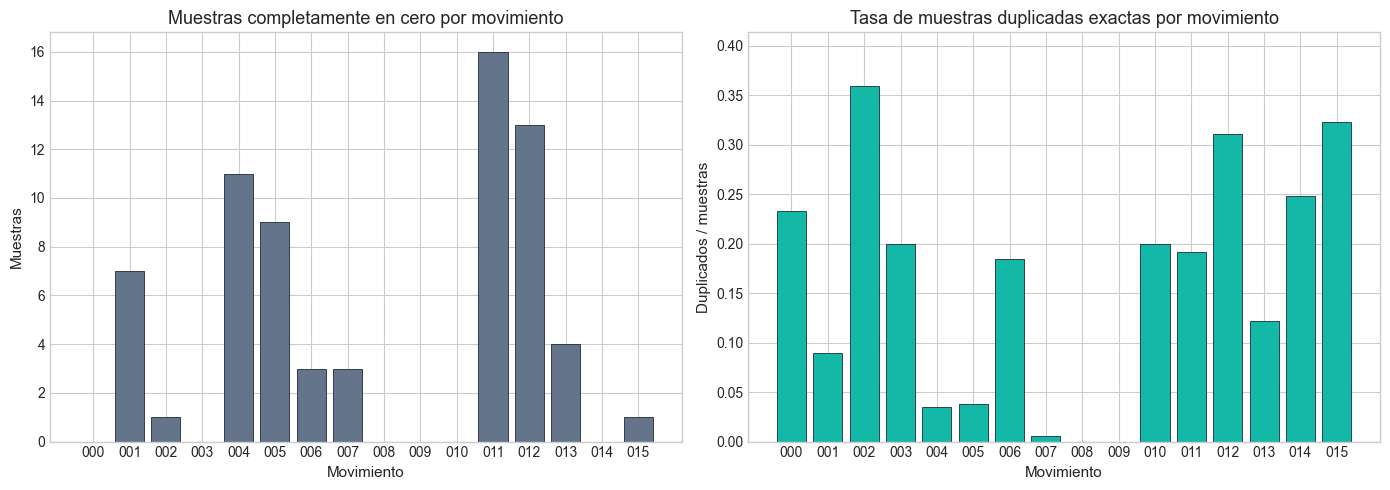

,metric,value
0,NaN en archivos validos,0
1,Infinitos en archivos validos,0
2,Muestras all-zero en sensor_id=2,68
3,Duplicados exactos en sensor_id=2,716
4,Duplicados exactos no-cero en sensor_id=2,658


In [21]:
quality_s2 = quality_table[quality_table["sensor_id"] == "2"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(quality_s2["movement_id"], quality_s2["all_zero_samples"], color="#64748b", edgecolor="#1f2937", linewidth=0.6)
axes[0].set_title("Muestras completamente en cero por movimiento")
axes[0].set_xlabel("Movimiento")
axes[0].set_ylabel("Muestras")

axes[1].bar(quality_s2["movement_id"], quality_s2["duplicate_rate"], color="#14b8a6", edgecolor="#1f2937", linewidth=0.6)
axes[1].set_title("Tasa de muestras duplicadas exactas por movimiento")
axes[1].set_xlabel("Movimiento")
axes[1].set_ylabel("Duplicados / muestras")
axes[1].set_ylim(0, max(quality_s2["duplicate_rate"].max() * 1.15, 0.05))

plt.tight_layout()
plt.show()

quality_summary = pd.DataFrame([
    {"metric": "NaN en archivos validos", "value": int(quality_table["nan_values"].sum())},
    {"metric": "Infinitos en archivos validos", "value": int(quality_table["infinite_values"].sum())},
    {"metric": "Muestras all-zero en sensor_id=2", "value": int(quality_s2["all_zero_samples"].sum())},
    {"metric": "Duplicados exactos en sensor_id=2", "value": int(quality_s2["duplicate_samples"].sum())},
    {"metric": "Duplicados exactos no-cero en sensor_id=2", "value": int(quality_s2["duplicate_nonzero_samples"].sum())},
])
display(quality_summary)


## 8. Conclusiones y siguientes pasos

**Conclusiones principales**

- El subconjunto de entrenamiento procesado contiene 16 movimientos, con 4,616 muestras usando `sensor_id=2`. Cada muestra tiene forma `880 x 6`.
- No se encontraron valores `NaN` ni infinitos en los archivos validos.
- `014_1.npy` esta corrupto: `np.load` no puede abrirlo y el primer byte no coincide con la firma esperada de NumPy. Ademas, su tamano es mayor al esperado para un arreglo `float64` con forma `359 x 880 x 6`. Para analisis con `sensor_id=1`, el movimiento 014 debe excluirse o el archivo debe descargarse de nuevo.
- Los movimientos estan moderadamente desbalanceados. Antes de entrenar un modelo, conviene usar metricas robustas por clase y revisar estrategias como class weights o muestreo estratificado.
- Existen muestras completamente en cero y duplicados exactos. Estos casos deben revisarse antes del modelado porque pueden representar padding, registros fallidos o repeticiones conservadas por el preprocesamiento.
- Los sensores pareados no contienen lecturas identicas: sus correlaciones dependen del movimiento y del eje. Esto es razonable porque capturan segmentos corporales distintos y pueden aportar informacion complementaria.

**Siguientes pasos recomendados**

1. Descargar de nuevo `014_1.npy` desde la fuente original o usar temporalmente solo `sensor_id=2` para incluir las 16 clases.
2. Definir una tabla final de features por muestra y documentar si se eliminaran duplicados/all-zero samples.
3. Separar entrenamiento y prueba de forma estratificada. Si se consiguen IDs de paciente o sesion, hacer el split por paciente para evitar fuga de informacion.
4. Comparar modelos con senales crudas, features agregadas y/o modelos secuenciales, segun el objetivo del reto.


## 9. Celda opcional: perfil automatizado

La guia menciona herramientas como `ydata-profiling` para automatizar reportes. En este caso los datos originales son senales 3D, asi que primero los convertimos a features tabulares (`features_s2`). La siguiente celda genera un HTML solo si la libreria esta instalada.


In [22]:
try:
    from ydata_profiling import ProfileReport

    profile_cols = ["movement_id", "movement_group", "zero_fraction", "all_zero_sample"] + feature_cols_s2
    profile = ProfileReport(
        features_s2[profile_cols],
        title="REHAB exercise - perfil EDA sensor_id=2",
        explorative=True,
        minimal=True,
    )
    output_path = PROJECT_ROOT / "rehab_exercise_sensor2_profile.html"
    profile.to_file(output_path)
    print(f"Reporte generado en: {output_path}")
except ImportError:
    print("ydata_profiling no esta instalado en este entorno. El EDA anterior queda completo y reproducible sin esa dependencia.")
except Exception as exc:
    print(f"No se pudo generar el perfil automatizado: {exc}")


ydata_profiling no esta instalado en este entorno. El EDA anterior queda completo y reproducible sin esa dependencia.
